In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
categorical_features = ['Season']
numerical_features = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Sunlight (W/m²)', 'Building Occupancy', 'Energy Tariff ($/kWh)', 'Energy Consumption (kWh)']

In [6]:
df = pd.read_csv(r"C:\Users\91995\OneDrive\Desktop\Sustainathon\DataSets\Updated_Environmental & External Factors.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace = True)

In [7]:
emission_factor = 0.5
df['CO2_Emissions'] = df['Energy Consumption (kWh)'] * emission_factor

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['Energy Consumption (kWh)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Sunlight (W/m²)', 'Building Occupancy', 'Energy Tariff ($/kWh)']]
y = df['CO2_Emissions']

# Split the data (corrected order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
print(f'MSE : {mean_squared_error(y_test, y_pred)}')
print(f'R2 : {r2_score(y_test, y_pred)}')

MSE : 9.315183177080578e-30
R2 : 1.0


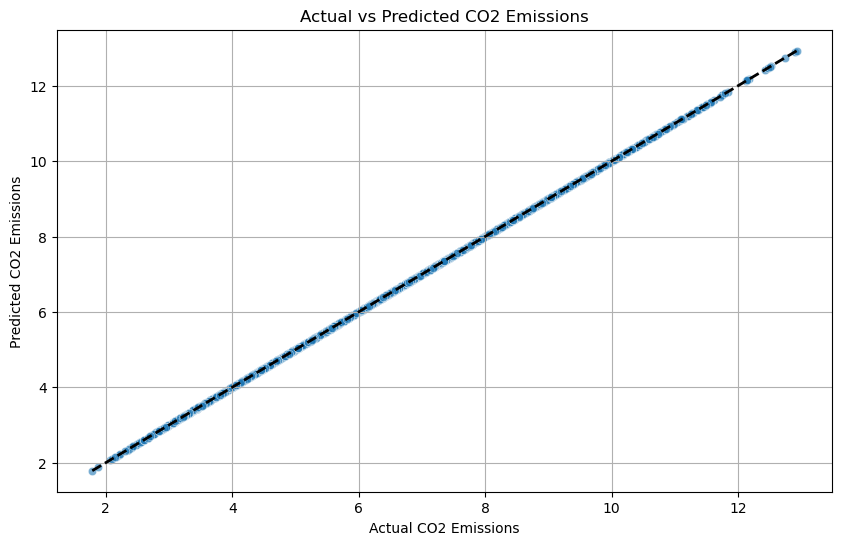

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the results
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line

# Labels and title
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Actual vs Predicted CO2 Emissions')
plt.grid(True)
plt.show()

In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print(f"MSE : {mean_squared_error(y_test, y_pred_xgb)}")  # Use a comma, not a dot
print(f"R2 : {r2_score(y_test, y_pred_xgb)}")   

MSE : 0.6857404928918298
R2 : 0.8634700080135004
